In [1]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import seaborn as sns 
data = pd.read_csv('train.csv')
df = pd.DataFrame(data)

def preprocessing(df):
    df = df.copy()
    df = df.drop(['Id', 'PID'], axis=1) #удаляем тк айди и пид никак не влияют на цену дома
    
    return df 

df = preprocessing(df)

In [4]:
sale_log = np.log1p(df['SalePrice'])

In [5]:
df['SalePrice'] = sale_log
features = df.drop('SalePrice', axis=1)
target = sale_log

numeric_cols = features.select_dtypes(include='number').columns
catigorail_cols = features.select_dtypes(include='object').columns

numeric_pipeline = Pipeline([
    ('impuet', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorial_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('coder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

X_train,X_test,y_train,y_test = train_test_split(features, target, test_size=0.2, random_state=10)

preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline, numeric_cols),
    ('cat', categorial_pipeline, catigorail_cols)
])

X_train_new = preprocessor.fit_transform(X_train)
X_test_new = preprocessor.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_new, y_train)
answ = lr.predict(X_test_new)
print('LinearRegression', r2_score(y_test, answ),'RMSE', np.sqrt(mean_squared_error(y_test,answ))) #самая простая линейная модель

ridge = Ridge(alpha=1)
ridge.fit(X_train_new, y_train)
answ2 = ridge.predict(X_test_new)
print('Ridge', r2_score(y_test, answ2),'RMSE', np.sqrt(mean_squared_error(y_test,answ2))) #

rf = RandomForestRegressor()
rf.fit(X_train_new, y_train)
answ3 = rf.predict(X_test_new)
print('RandomForestRegression', r2_score(y_test, answ3), 'RMSE', np.sqrt(mean_squared_error(y_test,answ3)))

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_new, y_train)
pred_lasso = lasso.predict(X_test_new)
print('Lasso', r2_score(y_test, pred_lasso), 'RMSE', np.sqrt(mean_squared_error(y_test,pred_lasso)))


/var/folders/mz/_dmjcgp12v90nvk18g95rs800000gn/T/ipykernel_58019/86980454.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catigorail_cols = features.select_dtypes(include='object').columns


LinearRegression 0.6681808853531503 RMSE 0.23540194077042922
Ridge 0.7090431783339963 RMSE 0.22043147714443923
RandomForestRegression 0.8392906960500192 RMSE 0.16382487641712715
Lasso 0.7022599020235598 RMSE 0.22298620812960993


без удаления признаков 
LinearRegression 0.6681808853531503 RMSE 0.23540194077042922
Ridge 0.7090431783339963 RMSE 0.22043147714443923
RandomForestRegression 0.8348038123595283 RMSE 0.16609606713237834

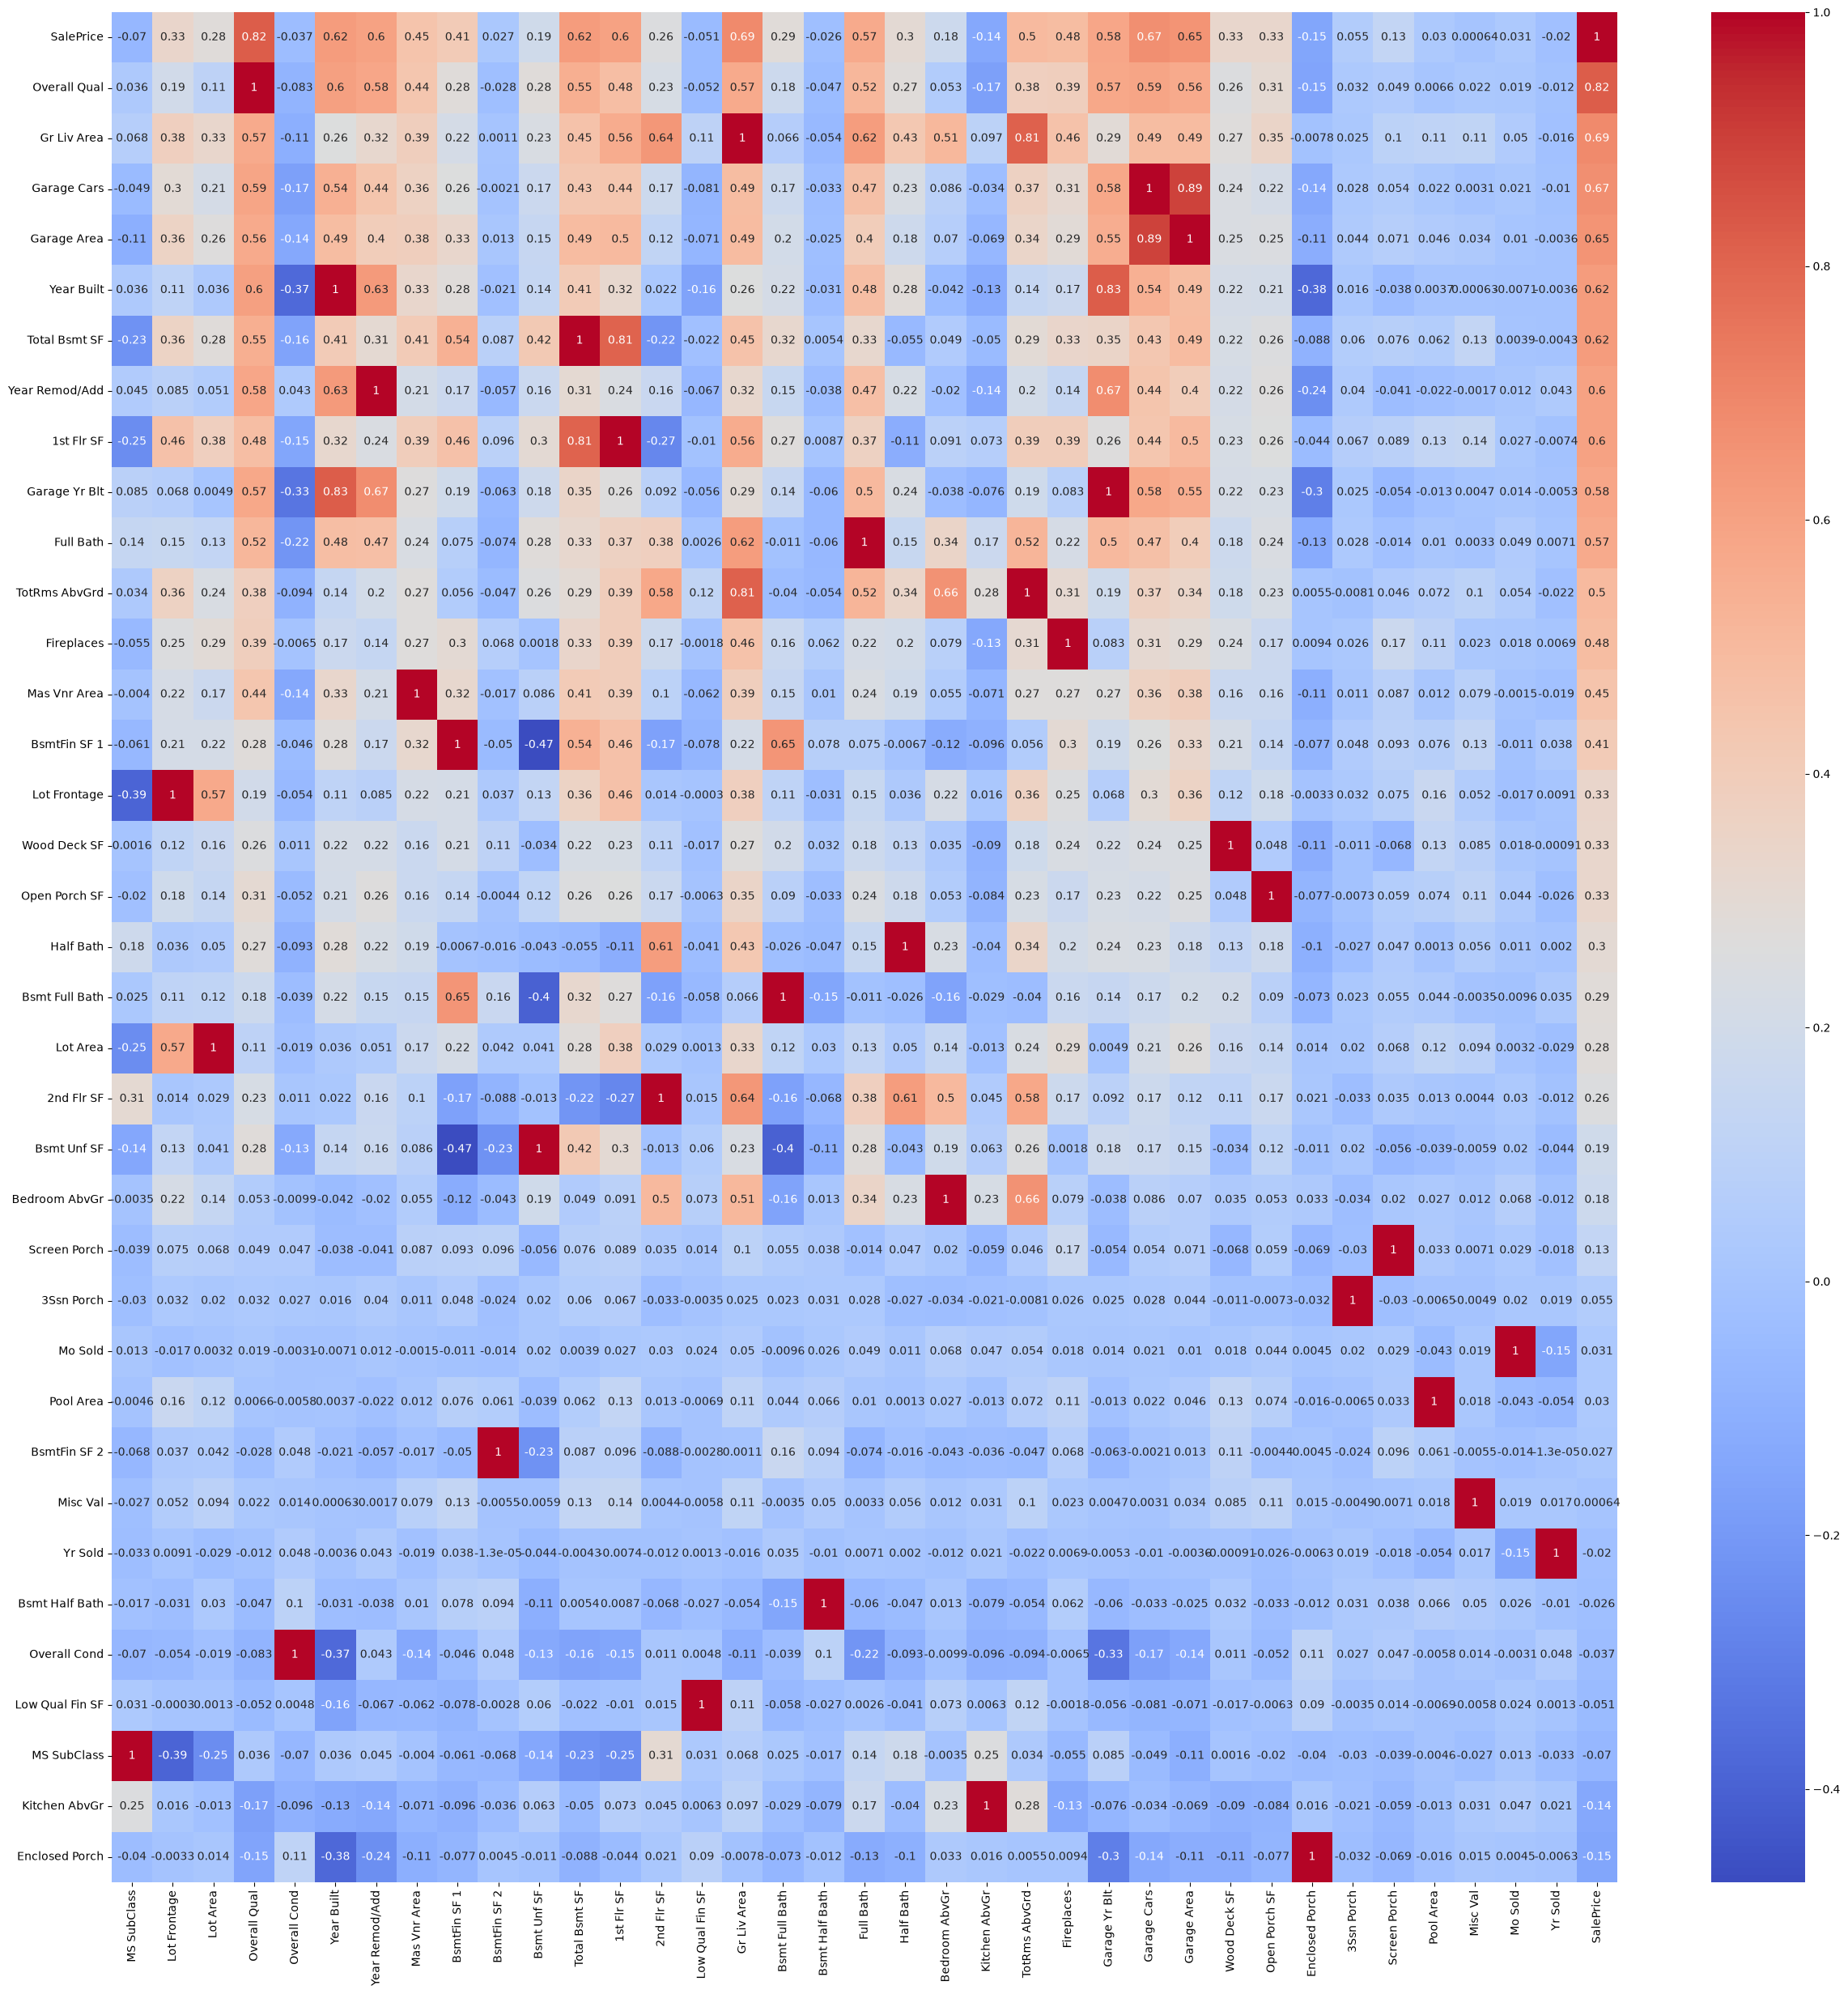

In [6]:
corr = df.corr(numeric_only=True)
sale_corr = corr.sort_values(ascending=False, by='SalePrice')

plt.figure(figsize=(30,30))
sns.heatmap(sale_corr, annot=True, cmap='coolwarm')
plt.show()

In [7]:
def drop_corrilated_priz(df, threshould = 0.75):
    corr = df.corr(numeric_only=True).abs()
    
    drop_col = set()
    
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if corr.iloc[i,j] > threshould:
                drop_col.add(cols[j])
    
    df = df.drop(columns=drop_col)
    print(drop_col)
    
    return df 

df = drop_corrilated_priz(df)

df['SalePrice'] = sale_log
features = df.drop('SalePrice', axis=1)
target = sale_log

numeric_cols = features.select_dtypes(include='number').columns
catigorail_cols = features.select_dtypes(include='object').columns

numeric_pipeline = Pipeline([
    ('impuet', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorial_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('coder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

X_train,X_test,y_train,y_test = train_test_split(features, target, test_size=0.2, random_state=10)

preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline, numeric_cols),
    ('cat', categorial_pipeline, catigorail_cols)
])

X_train_new = preprocessor.fit_transform(X_train)
X_test_new = preprocessor.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_new, y_train)
pred_lr = lr.predict(X_test_new)
print('LinearRegression', r2_score(y_test, answ),'RMSE', np.sqrt(mean_squared_error(y_test,pred_lr))) #самая простая линейная модель

ridge = Ridge(alpha=1)
ridge.fit(X_train_new, y_train)
pred_ridge = ridge.predict(X_test_new)
print('Ridge', r2_score(y_test, answ2),'RMSE', np.sqrt(mean_squared_error(y_test,pred_ridge))) #

rf = RandomForestRegressor()
rf.fit(X_train_new, y_train)
pred_rf = rf.predict(X_test_new)
print('RandomForestRegression', r2_score(y_test, answ3), 'RMSE', np.sqrt(mean_squared_error(y_test,pred_rf)))

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_new, y_train)
pred_lasso = lasso.predict(X_test_new)
print('Lasso', r2_score(y_test, pred_lasso), 'RMSE', np.sqrt(mean_squared_error(y_test,pred_lasso)))

{'Garage Yr Blt', 'SalePrice', 'TotRms AbvGrd', 'Garage Area', '1st Flr SF'}
LinearRegression 0.6681808853531503 RMSE 0.23382753731405584
Ridge 0.7090431783339963 RMSE 0.21965690230807072


/var/folders/mz/_dmjcgp12v90nvk18g95rs800000gn/T/ipykernel_58019/2655858030.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catigorail_cols = features.select_dtypes(include='object').columns


RandomForestRegression 0.8392906960500192 RMSE 0.16682843017683657
Lasso 0.7025116010717474 RMSE 0.22289193583750308


После удаления довольно коррелирующих между собой признаков мы увидили изменения:
До:
LinearRegression 0.6681808853531503 RMSE 0.23540194077042922
-------------------------------------------------------------------
Ridge 0.7090431783339963 RMSE 0.22043147714443923
-------------------------------------------------------------------
RandomForestRegression 0.8401277859654848 RMSE 0.16339766034699837
-------------------------------------------------------------------
Lasso 0.7022599020235598 RMSE 0.22298620812960993
После: 
LinearRegression 0.6726045545646833 RMSE 0.23382753731405584
-------------------------------------------------------------------
Ridge 0.7110843738573521 RMSE 0.21965690230807072
-------------------------------------------------------------------
RandomForestRegression 0.8342344819621157 RMSE 0.16272997673478
-------------------------------------------------------------------
Lasso 0.7022599020235598 RMSE 0.22298620812960993

Заметим, линейная регрессия улучшилась. Случайный лес чуть-чуть ухудшился, л2 улучшилось, л1 не поменялось На данный момент самая эффективная модель - случаный лес. л1 не подходит так как ничего не поменялось, но черег грид попробуем подкуртить ей парметры

In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


# params = ({
#     'max_depth': [2,4,6,8],
#     'eta': np.linspace(0.01, 1),
# })

# param_grid = GridSearchCV(
#     estimator=xgb, 
#     scoring='r2',
#     param_grid=params,
#     cv=5,
#     n_jobs=-1,
#     verbose=0
# )

# param_grid.fit(X_train_new, y_train)
# param_grid.predict(X_test_new)
# param_grid.best_params_
# {'eta': np.float64(0.15142857142857144), 'max_depth': 4}
xgb = XGBRegressor(eta=0.15, max_depth = 4)
xgb.fit(X_train_new, y_train)
pred_xgb = xgb.predict(X_test_new)
print(f'XGBRegressor: {r2_score(y_test, pred_xgb)} RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb))}')


XGBRegressor: 0.8844752757656594 RMSE: 0.13889826124973248
